# Neandertales Caffe — Class 2
## Feature Engineering — Creating New Columns

Last class we loaded the dataset, explored it and made our first charts.

Today:
1. **Recap** — same patterns, write from memory
2. **Bag size** — extract 500g / 1000g from the product name
3. **Date columns** — extract month, quarter, year safely
4. **New columns** — is_large_order, price_tier

> *"Every calculation gets its own variable. Every print is a separate step."*

# 0. Setup

In [1]:
# ── Google Colab ───────────────────────────────────────────
# from google.colab import files
# files.upload()

# ── VS Code ─────────────────────────────────────────────────
# Make sure neandertales_orders.csv is in the same folder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("neandertales_orders.csv")


print("Dataset ready!")
print("Shape:", orders.shape)
orders.head()

Dataset ready!
Shape: (223, 10)


,order_id,customer_id,customer,product_id,product,category,price,quantity,city,date
0,1001,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-05
1,1002,C003,Carol,P005,Ethiopia Natural 500g,Coffee,15.9,1,Munich,2024-01-10
2,1003,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-15
3,1004,C009,Iris,P009,Classic Mug 300ml,Accessories,9.9,1,Cologne,2024-01-20
4,1005,C013,Mia,P001,Espresso Blend 500g,Coffee,12.9,3,Berlin,2024-01-20


## Create the revenue column first

In [2]:
# Revenue = price x quantity
# Hint: df["new_col"] = df["col1"] * df["col2"]
orders["revenue"] = orders["price"] * orders["quantity"]

print("Revenue column created!")
print(orders[["product", "price", "quantity", "revenue"]].head(5))

Revenue column created!
                        product  price  quantity  revenue
0  Colombia Single Origin 1000g   27.9         1     27.9
1         Ethiopia Natural 500g   15.9         1     15.9
2  Colombia Single Origin 1000g   27.9         1     27.9
3             Classic Mug 300ml    9.9         1      9.9
4           Espresso Blend 500g   12.9         3     38.7


In [3]:
orders.head()

,order_id,customer_id,customer,product_id,product,category,price,quantity,city,date,revenue
0,1001,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-05,27.9
1,1002,C003,Carol,P005,Ethiopia Natural 500g,Coffee,15.9,1,Munich,2024-01-10,15.9
2,1003,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-15,27.9
3,1004,C009,Iris,P009,Classic Mug 300ml,Accessories,9.9,1,Cologne,2024-01-20,9.9
4,1005,C013,Mia,P001,Espresso Blend 500g,Coffee,12.9,3,Berlin,2024-01-20,38.7


# 1. Recap — Write It From Memory
No examples shown. Just the question and a small hint.
If you get stuck — the hint tells you which function to use.

## 1.1 — How many unique customers and products?

In [8]:
# Hint: df["col"].nunique()
unique_customers = orders["customer_id"].nunique()
unique_products  = orders["product_id"].nunique()
unique_categories  = orders["category"].nunique()


print("Customers:", unique_customers)
print("Products: ", unique_products)
print("Categories: ", unique_categories)

Customers: 30
Products:  15
Categories:  3


## 1.2 — Total revenue of the whole store

In [6]:
# Hint: df["col"].sum()
total_revenue = orders["revenue"].sum()

print("Total revenue:", round(total_revenue, 2), "euros")

Total revenue: 6182.9 euros


## 1.3 — Revenue per category, sorted highest first

In [11]:
# Step 1 — calculate revenue per category
# Hint: df.groupby("col")["col"].sum().round(2)
rev_by_cat = orders.groupby("category")["revenue"].sum().round(2)


# Step 2 — sort highest first
# Hint: df.sort_values(ascending=False)
rev_by_cat_sorted = rev_by_cat.sort_values(ascending=False)

# Step 3 — print
print(rev_by_cat_sorted)

category
Coffee         3799.9
Equipment      1460.9
Accessories     922.1
Name: revenue, dtype: float64


## 1.4 — Top 5 products by quantity sold

In [16]:
# Hint: df.groupby("col")["col"].sum().sort_values(ascending=False).head(5)
qty_by_product = orders.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)

qty_by_product_sorted = qty_by_product.sort_values(ascending=False)

print(qty_by_product_sorted.head(5))

product
Espresso Blend 500g            35
Ethiopia Natural 500g          35
Espresso Blend 1000g           33
Classic Mug 300ml              29
Colombia Single Origin 500g    28
Name: quantity, dtype: int64


## 1.5 — Bar chart of revenue per category

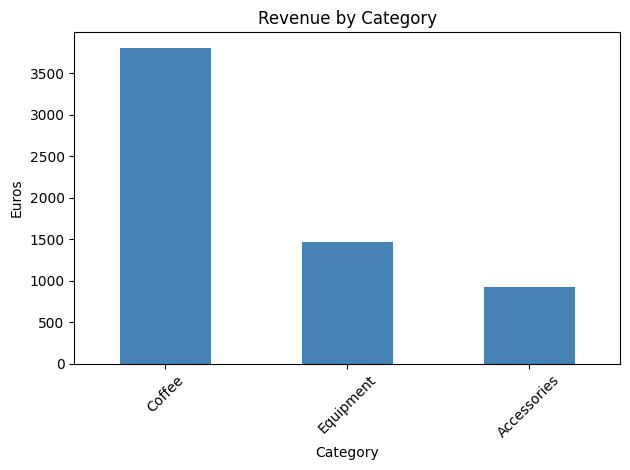

In [17]:
# Hint: df.plot(kind="bar")
rev_by_cat_sorted.plot(kind="bar", color="steelblue")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Euros")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2. Feature Engineering
> *"Feature engineering means creating new columns from existing ones.
> The raw data records what happened. New columns let you ask better questions."*

We will build these today:
| New column | Built from | What it tells us |
|---|---|---|
| `bag_size` | `product` name | 500g, 1000g, or no size |
| `month` | `date` | which month the order was placed |
| `quarter` | `date` | Q1, Q2, Q3, Q4 |
| `is_large_order` | `quantity` | True if 3 or more items |
| `price_tier` | `price` | Low, Mid, High |

## 2.1 — Bag Size
The size is hidden inside the product name. We need to extract it.

**The idea:** check if the string `"500g"` appears inside the product name.

In [ ]:
# First — understand the logic on one value
product_name = "Espresso Blend 500g"

print("1000g"  in product_name)


False


In [ ]:
# Different ways to extract information from text in Python
# All of these work on any string — product names, emails, addresses, anything

product = "Espresso Blend 500g"

# ── Check if something exists inside the text ────────────────
print("--- Contains ---")
print("Contains 500g?",   "500g"   in product)      # True
print("Contains 1000g?",  "1000g"  in product)      # False
print("Contains Blend?",  "Blend"  in product)      # True
print("Contains Latte?",  "Latte"  in product)      # False
print()

# ── Check how the text starts or ends ────────────────────────
print("--- Starts / Ends ---")
print("Starts with Espresso?", product.startswith("Espresso"))   # True
print("Starts with Colombia?", product.startswith("Colombia"))   # False
print("Ends with 500g?",       product.endswith("500g"))         # True
print("Ends with 1000g?",      product.endswith("1000g"))        # False
print()

# ── Split the text into parts ────────────────────────────────
print("--- Split ---")
parts = product.split(" ")           # split by space
print("Parts:", parts)               # ["Espresso", "Blend", "500g"]
print("Last part:", parts[-1])       # "500g"  — last word
print("First part:", parts[0])       # "Espresso" — first word
print()

# ── Replace part of the text ─────────────────────────────────
print("--- Replace ---")
clean = product.replace("500g", "").strip()   # remove "500g", strip spaces
print("Without size:", clean)                  # "Espresso Blend"
print()

# ── Upper and lower case ─────────────────────────────────────
print("--- Case ---")
print("Uppercase:", product.upper())           # "ESPRESSO BLEND 500G"
print("Lowercase:", product.lower())           # "espresso blend 500g"

In [ ]:
# Your turn — try the same operations on a different product
my_product = "Colombia Single Origin 1000g"

# Does it contain "Colombia"?
print("Contains Colombia:", "Colombia" in my_product)


# Does it end with "1000g"?
print("Ends with 1000g:", my_product.endswith("1000g"))

# Split by space and show the last part
parts = my_product.split("_")
print("Last part:", parts[___])

# Remove "1000g" from the name
clean = my_product.replace("_____", "").strip()
print("Without size:", clean)


Contains Colombia: True
Ends with 1000g: True


### Now wrap it in a function

In [21]:
# Before writing any extraction function — always check unique values first
# Hint: df["col"].unique()
unique_products = orders["product"].unique()

print("All unique products:")
for product in sorted(unique_products):
    print(" ", product)

All unique products:
  Classic Mug 300ml
  Cleaning Tablets x10
  Coffee Grinder Manual
  Colombia Single Origin 1000g
  Colombia Single Origin 500g
  Dark Roast Blend 1000g
  Dark Roast Blend 500g
  Espresso Blend 1000g
  Espresso Blend 500g
  Ethiopia Natural 1000g
  Ethiopia Natural 500g
  Filters V60 x100
  French Press 600ml
  Moka Pot
  Travel Mug 400ml


In [30]:
# More complete version — extracts the size and unit from any product name

def extract_size(product):
    if "500g" in product:
        return "500g"
    elif "1000g" in product:
        return "1000g"
    elif "300ml" in product:
        return "300ml"
    elif "400ml" in product:
        return "400ml"
    elif "600ml" in product:
        return "600ml"
    elif "x100" in product:      # Filters V60 x100
        return "x100"
    elif "x10" in product:       # Cleaning Tablets x10
        return "x10"
    else:
        return "No size"         # Moka Pot, Coffee Grinder

orders["size"] = orders["product"].apply(extract_size)



In [32]:
print(orders["size"].value_counts())

size
500g       76
1000g      63
300ml      21
No size    18
x100       13
600ml      12
400ml      10
x10        10
Name: count, dtype: int64


### Your turn — apply the function to every row

In [29]:
orders.head()

,order_id,customer_id,customer,product_id,product,category,price,quantity,city,date,revenue,size,bag_size
0,1001,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-05,27.9,1000g,1000g
1,1002,C003,Carol,P005,Ethiopia Natural 500g,Coffee,15.9,1,Munich,2024-01-10,15.9,500g,500g
2,1003,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-15,27.9,1000g,1000g
3,1004,C009,Iris,P009,Classic Mug 300ml,Accessories,9.9,1,Cologne,2024-01-20,9.9,300ml,300ml
4,1005,C013,Mia,P001,Espresso Blend 500g,Coffee,12.9,3,Berlin,2024-01-20,38.7,500g,500g


In [23]:
# Hint: df["col"].apply(function_name)
orders["bag_size"] = orders["product"].apply(extract_size)

# Check 1 — how many of each size?
# Hint: df["col"].value_counts()
bag_size_counts = orders["bag_size"].value_counts()

print("Count per size:")
print(bag_size_counts)
print()

# Check 2 — does it look right on actual rows?
# Hint: df[["col1","col2"]].head(10)
print("Product vs bag_size — first 10 rows:")
print(orders[["product", "bag_size"]].head(10))

Count per size:
bag_size
500g       76
1000g      63
300ml      21
No size    18
x100       13
600ml      12
400ml      10
x10        10
Name: count, dtype: int64

Product vs bag_size — first 10 rows:
                        product bag_size
0  Colombia Single Origin 1000g    1000g
1         Ethiopia Natural 500g     500g
2  Colombia Single Origin 1000g    1000g
3             Classic Mug 300ml    300ml
4           Espresso Blend 500g     500g
5          Espresso Blend 1000g    1000g
6  Colombia Single Origin 1000g    1000g
7                      Moka Pot  No size
8         Ethiopia Natural 500g     500g
9              Filters V60 x100     x100


### Your turn — total revenue per bag size

In [34]:
# Hint: df.groupby("col")["col"].sum().sort_values(ascending=False)
rev_by_size = orders.groupby("size")["revenue"].sum().round(2)

print(rev_by_size)

size
1000g      2160.5
300ml       287.1
400ml       373.5
500g       1639.4
600ml       593.3
No size     867.6
x10         103.5
x100        158.0
Name: revenue, dtype: float64


### Your turn — filter Coffee only, then compare 500g vs 1000g revenue

In [39]:
# Step 1 — filter Coffee only
# Hint: df[df["col"] == "value"]
coffee_only = orders[orders["category"] == "Coffee"]

# Step 2 — groupby bag_size, sum revenue
# Hint: df.groupby("col")["col"].sum()
coffee_size_rev = coffee_only.groupby("bag_size")["revenue"].sum().round(2)

coffee_size_sorted = coffee_size_rev.sort_values(ascending=False)

print(coffee_size_sorted)
print()
print("Does 500g or 1000g generate more coffee revenue? ___")

bag_size
1000g    2160.5
500g     1639.4
Name: revenue, dtype: float64

Does 500g or 1000g generate more coffee revenue? ___


In [45]:
orders.describe()

,order_id,price,quantity,date,revenue
count,223.000000,223.000000,223.000000,223,223.000000
mean,1069.753363,19.608520,1.439462,2024-07-01 21:31:28.789237760,27.726009
min,1001.000000,6.900000,1.000000,2024-01-05 00:00:00,6.900000
25%,1038.500000,12.900000,1.000000,2024-04-17 12:00:00,14.900000
50%,1071.000000,15.900000,1.000000,2024-06-25 00:00:00,22.900000
75%,1100.500000,27.900000,2.000000,2024-09-22 12:00:00,31.800000
max,1136.000000,44.900000,3.000000,2024-12-25 00:00:00,104.700000
std,37.599084,9.447831,0.674279,NaN,18.666018


## 2.2 — Extracting Month and Quarter from the Date
The `date` column is stored as text. We convert it to a real date
so we can extract month, quarter, and more.

In [40]:
# Step 1 — find the min and max dates in the dataset
# Hint: df["col"].min() and df["col"].max()
orders["date"] = pd.to_datetime(orders["date"])

min_date = orders["date"].min()
max_date = orders["date"].max()

print("First order:", min_date.date())
print("Last order: ", max_date.date())

First order: 2024-01-05
Last order:  2024-12-25


In [41]:
# Step 2 — create one row per day between those two dates
calendar = pd.DataFrame({
    "date": pd.date_range(start=min_date, end=max_date, freq="D")
})

calendar_rows = len(calendar)
print("Calendar rows:", calendar_rows)
print(calendar.head(5))

Calendar rows: 356
        date
0 2024-01-05
1 2024-01-06
2 2024-01-07
3 2024-01-08
4 2024-01-09


In [46]:
# Step 3 — extract useful columns from the date
# Hint: df["date_col"].dt.to_period("M") for year+month
calendar["year"]       = calendar["date"].dt.to_period("Y")   # 2024
calendar["quarter"]    = calendar["date"].dt.to_period("Q")   # 2024Q1
calendar["year_month"] = calendar["date"].dt.to_period("M")   # 2024-01
calendar["month_name"] = calendar["date"].dt.month_name()     # January
calendar["day_name"]   = calendar["date"].dt.day_name()       # Monday
calendar["is_weekend"] = calendar["date"].dt.day_of_week >= 5 # True/False

print("Calendar table:")
print(calendar.head(10).to_string(index=False))

Calendar table:
      date year quarter year_month month_name  day_name  is_weekend
2024-01-05 2024  2024Q1    2024-01    January    Friday       False
2024-01-06 2024  2024Q1    2024-01    January  Saturday        True
2024-01-07 2024  2024Q1    2024-01    January    Sunday        True
2024-01-08 2024  2024Q1    2024-01    January    Monday       False
2024-01-09 2024  2024Q1    2024-01    January   Tuesday       False
2024-01-10 2024  2024Q1    2024-01    January Wednesday       False
2024-01-11 2024  2024Q1    2024-01    January  Thursday       False
2024-01-12 2024  2024Q1    2024-01    January    Friday       False
2024-01-13 2024  2024Q1    2024-01    January  Saturday        True
2024-01-14 2024  2024Q1    2024-01    January    Sunday        True


In [47]:
# Step 4 — join calendar back to orders
# Hint: df.merge(other_df, on="shared_col", how="left")
orders = orders.merge(calendar, on="date", how="left")

print("Orders now have all date columns:")
print(orders[["date", "year_month", "quarter", "day_name", "is_weekend"]].head(5))

Orders now have all date columns:
        date year_month quarter   day_name  is_weekend
0 2024-01-05    2024-01  2024Q1     Friday       False
1 2024-01-10    2024-01  2024Q1  Wednesday       False
2 2024-01-15    2024-01  2024Q1     Monday       False
3 2024-01-20    2024-01  2024Q1   Saturday        True
4 2024-01-20    2024-01  2024Q1   Saturday        True


In [48]:
orders.head()

,order_id,customer_id,customer,product_id,product,category,price,quantity,city,date,revenue,size,bag_size,year,quarter,year_month,month_name,day_name,is_weekend
0,1001,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-05,27.9,1000g,1000g,2024,2024Q1,2024-01,January,Friday,False
1,1002,C003,Carol,P005,Ethiopia Natural 500g,Coffee,15.9,1,Munich,2024-01-10,15.9,500g,500g,2024,2024Q1,2024-01,January,Wednesday,False
2,1003,C003,Carol,P004,Colombia Single Origin 1000g,Coffee,27.9,1,Munich,2024-01-15,27.9,1000g,1000g,2024,2024Q1,2024-01,January,Monday,False
3,1004,C009,Iris,P009,Classic Mug 300ml,Accessories,9.9,1,Cologne,2024-01-20,9.9,300ml,300ml,2024,2024Q1,2024-01,January,Saturday,True
4,1005,C013,Mia,P001,Espresso Blend 500g,Coffee,12.9,3,Berlin,2024-01-20,38.7,500g,500g,2024,2024Q1,2024-01,January,Saturday,True


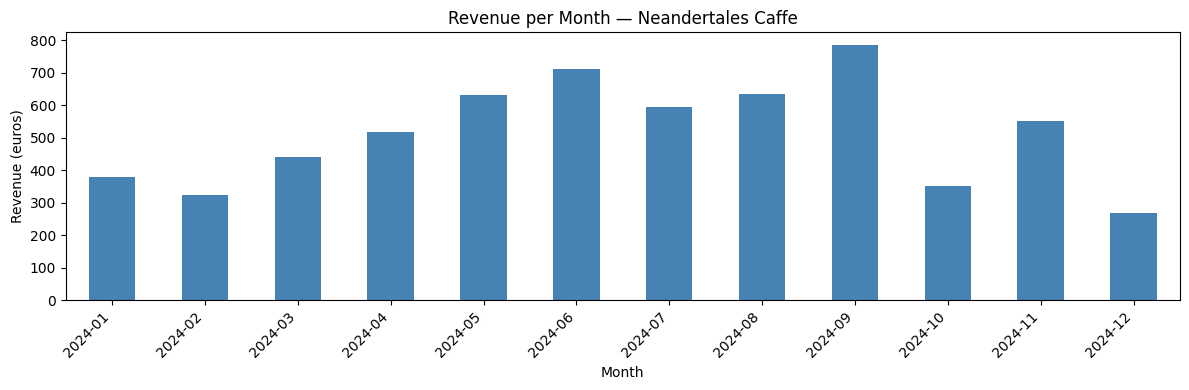

In [49]:
# Step 5 — now group by year_month — safe across multiple years
# Hint: df.groupby("col")["col"].sum()
rev_per_month = orders.groupby("year_month")["revenue"].sum()

# Convert period to string before plotting
rev_per_month.index = rev_per_month.index.astype(str)

rev_per_month.plot(kind="bar", color="steelblue", figsize=(12, 4))

plt.title("Revenue per Month — Neandertales Caffe")
plt.xlabel("Month")
plt.ylabel("Revenue (euros)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Your turn — extract the quarter (1, 2, 3 or 4)

In [ ]:
# Hint: df["col"].dt.to_period("frequency")
# Frequency options: "M" = month, "Q" = quarter, "Y" = year, "W" = week

# Step 1 — extract quarter
orders["quarter"] = orders["date"].dt.to_period("Q")

# Step 2 — count orders per quarter
quarter_counts = orders["quarter"].value_counts().sort_index()
print("Orders per quarter:")
print(quarter_counts)
print()

# Step 3 — now try the others yourself
# Your turn — extract year_month
orders["year_month"] = orders["date"].dt.to_period("___")

year_month_counts = orders["year_month"].value_counts().sort_index()
print("Orders per month:")
print(year_month_counts)
print()

# Your turn — extract year
orders["year"] = orders["date"].dt.to_period("___")

year_counts = orders["year"].value_counts().sort_index()
print("Orders per year:")
print(year_counts)

Orders per quarter:
quarter
2024Q1    44
2024Q2    73
2024Q3    58
2024Q4    48
Freq: Q-DEC, Name: count, dtype: int64



### Your turn — revenue per quarter

In [ ]:
# Hint: df.groupby("col")["col"].sum()
rev_per_quarter = orders.groupby("_______")["_______"]._____().round(2)

print(rev_per_quarter)
print()
print("Q1 = Jan-Mar   Q2 = Apr-Jun   Q3 = Jul-Sep   Q4 = Oct-Dec")

### Your turn — bar chart of revenue per month

In [ ]:
# Step 1 — calculate
# Hint: df.groupby("col")["col"].sum()
rev_per_month = orders.groupby("_____")["_______"]._____().round(2)

# Step 2 — convert index for plotting
rev_per_month.index = rev_per_month.index.astype(str)

# Step 3 — plot
___________.plot(kind="bar", color="steelblue", figsize=(12, 4))

plt.title("Neandertales Caffe — Revenue per Month")
plt.xlabel("Month")
plt.ylabel("Revenue (euros)")
plt.xticks(rotation=___, ha="right")

plt.tight_layout()
plt.show()

# Quick Reference — Date Periods

In [ ]:
# ── DATE PERIODS — QUICK REFERENCE ──────────────────────────────────────────

# Always start here — convert text to datetime
df["date"] = pd.to_datetime(df["date"])

# ── The safe way — year + unit together ─────────────────────────────────────

df["year_month"] = df["date"].dt.to_period("M")   # 2024-01  (January 2024)
df["quarter"]    = df["date"].dt.to_period("Q")   # 2024Q1   (Jan-Mar 2024)
df["year"]       = df["date"].dt.to_period("Y")   # 2024
df["week"]       = df["date"].dt.to_period("W")   # 2024-W03 (week 3 of 2024)
df["day"]        = df["date"].dt.to_period("D")   # 2024-01-15

# ── The unsafe way — only use if your data has ONE year ─────────────────────

df["month_num"]  = df["date"].dt.month            # 1  (January — from any year)
df["month_name"] = df["date"].dt.month_name()     # "January" — from any year
df["day_name"]   = df["date"].dt.day_name()       # "Monday"

# ── Using periods in groupby ─────────────────────────────────────────────────

# Correct — each month is unique even across years
df.groupby("year_month")["revenue"].sum()

# Correct — each quarter is unique even across years
df.groupby("quarter")["revenue"].sum()

# ── Using periods in charts ──────────────────────────────────────────────────

rev = df.groupby("year_month")["revenue"].sum()

# Convert period to string before plotting — matplotlib needs this
rev.index = rev.index.astype(str)

rev.plot(kind="bar", color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.show()

# ── Check the result ─────────────────────────────────────────────────────────
print(df[["date", "year_month", "quarter", "year", "day"]].head(8))

## 2.3 — Two More Columns

In [ ]:
# Example — is_large_order: True if quantity is 3 or more
# Hint: df["col"] >= value  creates a True/False column
orders["is_large_order"] = _______________________________

large_counts = orders["is_large_order"].value_counts()
print(large_counts)

large_pct = orders["is_large_order"].mean() * 100
print()
print("Large orders:", round(large_pct, 1), "% of all rows")

### Your turn — create `price_tier` column
Low = below 15 euros, Mid = 15 to 35 euros, High = above 35 euros

In [ ]:
# Step 1 — write the function
# Hint: use if / elif / else with price thresholds
def classify_price(price):
    ____________________:
        return "Low"
    _________________ <= ___:
        return "Mid"
    ____________:
        return "High"

# Step 2 — apply to every row
# Hint: df["col"].apply(function_name)
orders["price_tier"] = orders["_____"].apply(_______________)

# Step 3 — check distribution
tier_counts = orders["price_tier"].value_counts()
print(tier_counts)

### Your turn — what is the average revenue per price tier?

In [ ]:
# Hint: df.groupby("col")["col"].mean().sort_values(ascending=False)
avg_rev_tier = orders.groupby("__________")["_______"]._____().round(2)

avg_rev_tier_sorted = avg_rev_tier.sort_values(ascending=False)
print(avg_rev_tier_sorted)

# Challenge
One question — write everything yourself.

## Challenge 1 — Bar chart of revenue per bag size
Filter Coffee orders only, group by bag_size, sum revenue, plot a bar chart.
Add a title and axis labels.

**Hint:** filter → groupby → sum → plot

In [ ]:

# Challenge 1 — bar chart revenue per bag size (Coffee only)

# Step 1 — filter Coffee orders only
# Hint: df[df["col"] == "value"]
coffee = orders[orders["________"] == "______"]

print("Coffee orders:", len(coffee))

In [ ]:
# Step 2 — calculate revenue per bag size
# Hint: df.groupby("col")["col"].sum()
rev_by_size = 


# Step 3 — sort highest first
# Hint: df.sort_values(ascending=False)
rev_by_size_sorted = 

# Step 4 — print
print(rev_by_size_sorted.round(2))

In [ ]:
# Step 5 — plot a bar chart
# Hint: df.plot(kind="bar", color="steelblue", edgecolor="white")
___________.plot(kind="___", color="steelblue", edgecolor="white")

plt.title("___")
plt.xlabel("___")
plt.ylabel("___")
plt.xticks(rotation=___)

plt.tight_layout()
plt.show()

## Challenge 2 — Which quarter had the most orders?
Count the number of unique orders per quarter.
Print the result sorted highest first.

**Hint:** groupby quarter, nunique on order_id, sort

In [ ]:
# Your code here


# Answers — only open after you tried!

In [ ]:
# Challenge 1 — bar chart revenue per bag size (Coffee only)
coffee = orders[orders["category"] == "Coffee"]

rev_by_size = coffee.groupby("bag_size")["revenue"].sum().sort_values(ascending=False)

rev_by_size.plot(kind="bar", color="steelblue", edgecolor="white")

plt.title("Coffee Revenue — 500g vs 1000g")
plt.xlabel("Bag Size")
plt.ylabel("Total Revenue (euros)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(rev_by_size.round(2))

In [ ]:
# Challenge 2 — orders per quarter
orders_per_quarter = orders.groupby("quarter")["order_id"].nunique()

orders_per_quarter_sorted = orders_per_quarter.sort_values(ascending=False)
orders_per_quarter.index  = orders_per_quarter.index.astype(str)

print("Orders per quarter:")
print(orders_per_quarter_sorted)